In [52]:
# CELL 1

from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config

In [53]:
# CELL 2

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

PROCESS_KEYS = ["trucking", "warehouse", "customs"]

process_cfgs = {k: get_process_config(k) for k in PROCESS_KEYS}
process_report_dirs = {
    k: to_abs_path(process_cfgs[k].report_dir, PROJECT_ROOT)
    for k in PROCESS_KEYS
}

SHARED_REPORT_DIR = PROJECT_ROOT / "reports" / "cross_process"
SHARED_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SHARED_REPORT_DIR:", SHARED_REPORT_DIR)

for k, v in process_report_dirs.items():
    print(f"{k}: {v}")

PROJECT_ROOT: D:\logistics_AI
SHARED_REPORT_DIR: D:\logistics_AI\reports\cross_process
trucking: D:\logistics_AI\reports\trucking
warehouse: D:\logistics_AI\reports\warehouse
customs: D:\logistics_AI\reports\customs


In [54]:
# CELL 3

mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

PROCESS_COLOR_MAP = {
    "trucking": "#1f4e79",
    "warehouse": "#ed7d31",
    "customs": "#70ad47",
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [55]:
# CELL 4

def safe_read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Could not read CSV: {path} -> {e}")
        return None

def safe_read_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"Could not read JSON: {path} -> {e}")
        return None

artifact_index_rows = []

for process_key in PROCESS_KEYS:
    report_dir = process_report_dirs[process_key]
    monitoring_dir = report_dir / "monitoring"

    row = {
        "process_key": process_key,
        "report_dir_exists": report_dir.exists(),
        "summary_metrics_csv": (report_dir / f"{process_key}_summary_metrics.csv").exists(),
        "validation_summary_csv": (report_dir / f"{process_key}_validation_summary.csv").exists(),
        "case_level_results_csv": (report_dir / f"{process_key}_case_level_results.csv").exists(),
        "monitoring_summary_csv": (monitoring_dir / f"{process_key}_monitoring_summary.csv").exists(),
        "monthly_monitoring_csv": (monitoring_dir / f"{process_key}_monthly_monitoring.csv").exists(),
        "drift_summary_csv": (monitoring_dir / f"{process_key}_drift_summary.csv").exists(),
        "train_summary_json": (report_dir / f"{process_key}_train_summary_snapshot.json").exists(),
    }
    artifact_index_rows.append(row)

artifact_index_df = pd.DataFrame(artifact_index_rows)
display(artifact_index_df)

,process_key,report_dir_exists,summary_metrics_csv,validation_summary_csv,case_level_results_csv,monitoring_summary_csv,monthly_monitoring_csv,drift_summary_csv,train_summary_json
0,trucking,True,True,True,True,True,True,True,True
1,warehouse,True,True,True,True,True,True,True,True
2,customs,True,True,True,True,True,True,True,True


In [56]:
# CELL 5

summary_metrics_frames = []
validation_summary_frames = []
monitoring_summary_frames = []
drift_summary_frames = []
monthly_monitoring_frames = []
train_summary_rows = []

for process_key in PROCESS_KEYS:
    report_dir = process_report_dirs[process_key]
    monitoring_dir = report_dir / "monitoring"

    summary_metrics_df = safe_read_csv(report_dir / f"{process_key}_summary_metrics.csv")
    if summary_metrics_df is not None:
        summary_metrics_df["process_key"] = process_key
        summary_metrics_frames.append(summary_metrics_df)

    validation_summary_df = safe_read_csv(report_dir / f"{process_key}_validation_summary.csv")
    if validation_summary_df is not None:
        validation_summary_df["process_key"] = process_key
        validation_summary_frames.append(validation_summary_df)

    monitoring_summary_df = safe_read_csv(monitoring_dir / f"{process_key}_monitoring_summary.csv")
    if monitoring_summary_df is not None:
        monitoring_summary_df["process_key"] = process_key
        monitoring_summary_frames.append(monitoring_summary_df)

    drift_summary_df = safe_read_csv(monitoring_dir / f"{process_key}_drift_summary.csv")
    if drift_summary_df is not None:
        drift_summary_df["process_key"] = process_key
        drift_summary_frames.append(drift_summary_df)

    monthly_monitoring_df = safe_read_csv(monitoring_dir / f"{process_key}_monthly_monitoring.csv")
    if monthly_monitoring_df is not None:
        monthly_monitoring_df["process_key"] = process_key
        monthly_monitoring_frames.append(monthly_monitoring_df)

    train_summary_json = safe_read_json(report_dir / f"{process_key}_train_summary_snapshot.json")
    if train_summary_json is not None:
        train_summary_json["process_key"] = process_key
        train_summary_rows.append(train_summary_json)

summary_metrics_all_df = pd.concat(summary_metrics_frames, ignore_index=True) if summary_metrics_frames else pd.DataFrame()
validation_summary_all_df = pd.concat(validation_summary_frames, ignore_index=True) if validation_summary_frames else pd.DataFrame()
monitoring_summary_all_df = pd.concat(monitoring_summary_frames, ignore_index=True) if monitoring_summary_frames else pd.DataFrame()
drift_summary_all_df = pd.concat(drift_summary_frames, ignore_index=True) if drift_summary_frames else pd.DataFrame()
monthly_monitoring_all_df = pd.concat(monthly_monitoring_frames, ignore_index=True) if monthly_monitoring_frames else pd.DataFrame()
train_summary_all_df = pd.DataFrame(train_summary_rows)

print("summary_metrics_all_df:", summary_metrics_all_df.shape)
print("validation_summary_all_df:", validation_summary_all_df.shape)
print("monitoring_summary_all_df:", monitoring_summary_all_df.shape)
print("drift_summary_all_df:", drift_summary_all_df.shape)
print("monthly_monitoring_all_df:", monthly_monitoring_all_df.shape)
print("train_summary_all_df:", train_summary_all_df.shape)

summary_metrics_all_df: (24, 3)
validation_summary_all_df: (3, 10)
monitoring_summary_all_df: (3, 10)
drift_summary_all_df: (3, 15)
monthly_monitoring_all_df: (11, 8)
train_summary_all_df: (3, 11)


In [57]:
# CELL 6

display(summary_metrics_all_df)
display(validation_summary_all_df)
display(monitoring_summary_all_df)
display(drift_summary_all_df)

,metric,value,process_key
0,process_code,TRUCKING_DELIVERY_FLOW,trucking
1,num_step_codes,29,trucking
2,validated_event_rows,348000,trucking
3,num_cases,12000,trucking
4,num_features,38,trucking
5,dropped_cases,0,trucking
6,repeated_case_count,0,trucking
7,missing_step_cases,0,trucking
8,process_code,WAREHOUSE_FULFILLMENT,warehouse
9,num_step_codes,23,warehouse


,process_code,cases_analyzed,cases_ok,avg_risk,p95_risk,high_risk_cases_80plus,high_risk_rate_80plus,avg_top_step_duration_min,avg_top_step_deviation_p95,process_key
0,TRUCKING_DELIVERY_FLOW,12000,12000,49.500083,94.05,2400,0.200000,85.106537,1.307340,trucking
1,WAREHOUSE_FULFILLMENT,12000,12000,49.500083,94.05,2400,0.200000,53.991848,1.239750,warehouse
2,IMPORT_CUSTOMS_CLEARANCE,4286,4286,49.500700,94.75,858,0.200187,409.514820,1.117738,customs


,process_code,cases_analyzed,cases_ok,avg_risk,p95_risk,high_risk_cases_80plus,high_risk_rate_80plus,critical_cases,critical_rate,process_key
0,TRUCKING_DELIVERY_FLOW,12000,12000,49.500083,94.05,2400,20.000000,2833,23.608333,trucking
1,WAREHOUSE_FULFILLMENT,12000,12000,49.500083,94.05,2400,20.000000,2279,18.991667,warehouse
2,IMPORT_CUSTOMS_CLEARANCE,4286,4286,49.500700,94.75,858,20.018665,471,10.989267,customs


,reference_months,recent_months,avg_risk_ref,avg_risk_recent,avg_risk_delta,p95_risk_ref,p95_risk_recent,p95_risk_delta,high_risk_rate_ref,high_risk_rate_recent,high_risk_rate_delta,critical_rate_ref,critical_rate_recent,critical_rate_delta,process_key
0,"2025-04, 2025-05, 2025-06","2025-05, 2025-06, 2025-07",49.475153,50.046973,0.571821,94.333333,95.000000,0.666667,20.001373,19.376209,-0.625163,23.582430,24.270809,0.688379,trucking
1,"2025-04, 2025-05, 2025-06","2025-04, 2025-05, 2025-06",49.506892,49.506892,0.000000,94.333333,94.333333,0.000000,20.007350,20.007350,0.000000,18.997562,18.997562,0.000000,warehouse
2,"2025-04, 2025-05, 2025-06","2025-05, 2025-06, 2025-07",49.522568,48.208255,-1.314314,94.233333,93.683333,-0.550000,19.989432,22.953866,2.964434,11.009458,9.635229,-1.374229,customs


In [58]:
# CELL 7

portfolio_df = validation_summary_all_df.merge(
    monitoring_summary_all_df[
        ["process_key", "critical_rate"]
    ],
    on="process_key",
    how="left",
)

portfolio_df = portfolio_df[
    [
        "process_key",
        "cases_analyzed",
        "avg_risk",
        "p95_risk",
        "high_risk_rate_80plus",
        "critical_rate",
    ]
].copy()

for col in ["cases_analyzed", "avg_risk", "p95_risk", "high_risk_rate_80plus", "critical_rate"]:
    if col in portfolio_df.columns:
        portfolio_df[col] = pd.to_numeric(portfolio_df[col], errors="coerce")

display(portfolio_df)

,process_key,cases_analyzed,avg_risk,p95_risk,high_risk_rate_80plus,critical_rate
0,trucking,12000,49.500083,94.05,0.200000,23.608333
1,warehouse,12000,49.500083,94.05,0.200000,18.991667
2,customs,4286,49.500700,94.75,0.200187,10.989267


In [59]:
# CELL 8

fig, ax = plt.subplots(figsize=(10, 6))

sizes = portfolio_df["cases_analyzed"].fillna(0).astype(float)
sizes = np.where(sizes > 0, sizes / sizes.max() * 1600, 300)

for _, row in portfolio_df.iterrows():
    ax.scatter(
        row["avg_risk"],
        row["p95_risk"],
        s=sizes[portfolio_df.index.get_loc(row.name)],
        color=PROCESS_COLOR_MAP.get(row["process_key"], SECONDARY),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.8,
    )

    ax.text(
        row["avg_risk"] + 0.4,
        row["p95_risk"] + 0.4,
        row["process_key"].upper(),
        fontsize=10,
        weight="bold",
    )

ax.set_title("Cross-Process Risk Portfolio Overview")
ax.set_xlabel("Average Risk")
ax.set_ylabel("P95 Risk")
style_axes(ax, grid_axis="both")

portfolio_path = SHARED_REPORT_DIR / "cross_process_risk_portfolio.png"
save_and_show(fig, portfolio_path)

C:\Users\paper\AppData\Local\Temp\ipykernel_13728\3397472928.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved: D:\logistics_AI\reports\cross_process\cross_process_risk_portfolio.png


In [60]:
# CELL 9

high_risk_share_df = portfolio_df[
    ["process_key", "high_risk_rate_80plus"]
].copy().sort_values("high_risk_rate_80plus", ascending=False)

display(high_risk_share_df)

,process_key,high_risk_rate_80plus
2,customs,0.200187
0,trucking,0.200000
1,warehouse,0.200000


,process_key,critical_rate
2,customs,10.989267
1,warehouse,18.991667
0,trucking,23.608333


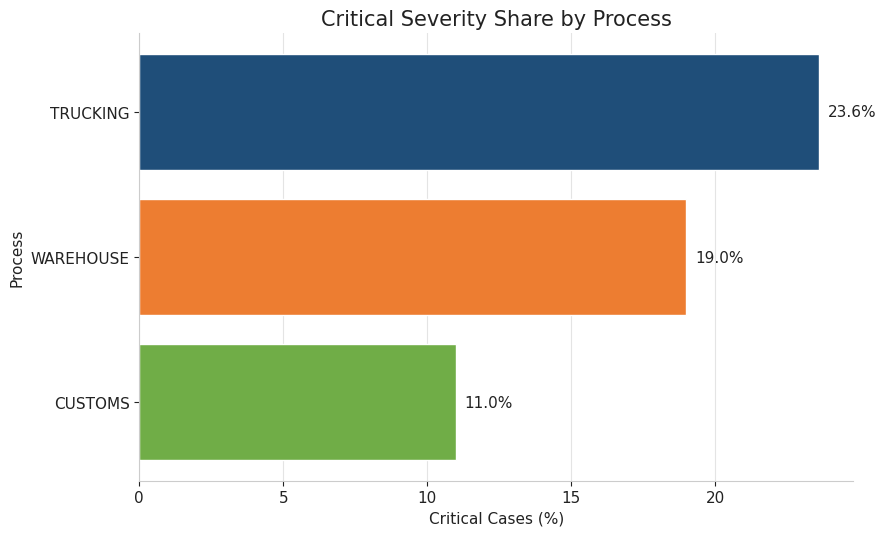

Saved: D:\logistics_AI\reports\cross_process\cross_process_critical_share.png


In [61]:
# CELL 10

critical_plot_df = monitoring_summary_all_df[
    ["process_key", "critical_rate"]
].copy()

critical_plot_df["critical_rate"] = pd.to_numeric(critical_plot_df["critical_rate"], errors="coerce")
critical_plot_df = critical_plot_df.sort_values("critical_rate", ascending=True)

display(critical_plot_df)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(
    critical_plot_df["process_key"].str.upper(),
    critical_plot_df["critical_rate"],
    color=[PROCESS_COLOR_MAP.get(x, SECONDARY) for x in critical_plot_df["process_key"]],
    edgecolor="white",
)

ax.set_title("Critical Severity Share by Process")
ax.set_xlabel("Critical Cases (%)")
ax.set_ylabel("Process")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", ha="left")

critical_share_path = SHARED_REPORT_DIR / "cross_process_critical_share.png"
save_and_show(fig, critical_share_path)

In [62]:
# CELL 11

monthly_plot_df = monthly_monitoring_all_df.copy()

for col in ["avg_risk", "p95_risk", "high_risk_rate", "critical_rate"]:
    if col in monthly_plot_df.columns:
        monthly_plot_df[col] = pd.to_numeric(monthly_plot_df[col], errors="coerce")

monthly_plot_df = monthly_plot_df.sort_values(["month", "process_key"])

display(monthly_plot_df.head(20))

,month,case_count,avg_risk,p95_risk,avg_anomaly,high_risk_rate,critical_rate,process_key
7,2025-04,1367,49.942941,94.70,0.427473,19.678127,11.265545,customs
0,2025-04,3782,48.982813,94.00,0.409806,19.116869,23.796933,trucking
4,2025-04,3915,49.808174,94.00,0.413649,20.842912,19.412516,warehouse
8,2025-05,1443,49.758143,95.00,0.427365,21.275121,11.434511,customs
1,2025-05,4147,49.850735,95.00,0.410833,20.786110,24.017362,trucking
5,2025-05,4153,49.160366,95.00,0.412990,19.672526,18.709367,warehouse
9,2025-06,1462,48.866621,93.00,0.425505,19.015048,10.328317,customs
2,2025-06,3955,49.591909,94.00,0.410292,20.101138,22.932996,trucking
6,2025-06,3932,49.552136,94.00,0.413037,19.506612,18.870804,warehouse
10,2025-07,14,46.000000,93.05,0.425138,28.571429,7.142857,customs


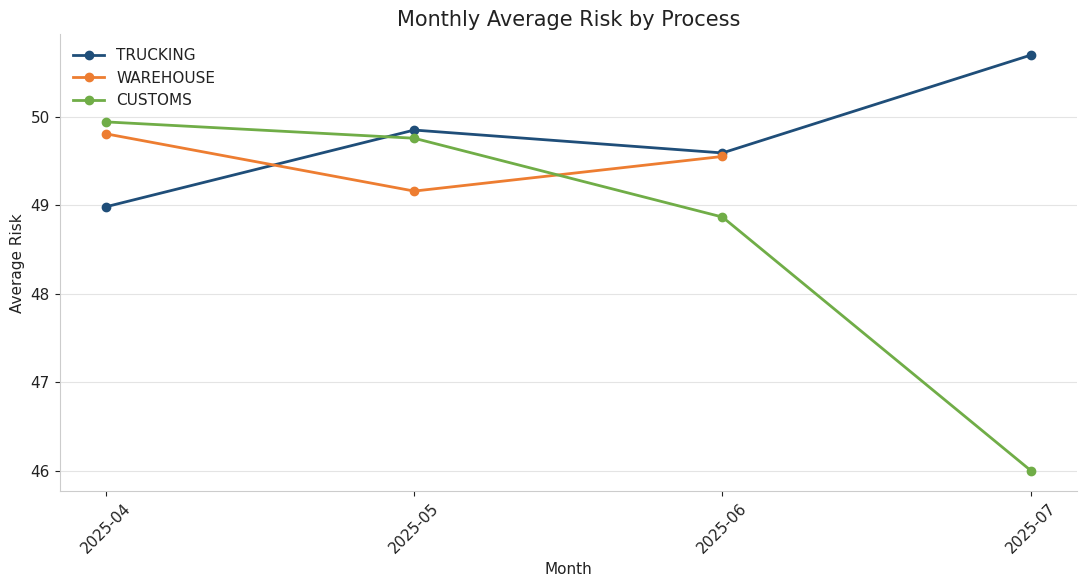

Saved: D:\logistics_AI\reports\cross_process\cross_process_monthly_avg_risk.png


In [63]:
# CELL 12

fig, ax = plt.subplots(figsize=(11, 6))

for process_key in PROCESS_KEYS:
    part = monthly_plot_df[monthly_plot_df["process_key"] == process_key].copy()
    if part.empty:
        continue

    ax.plot(
        part["month"],
        part["avg_risk"],
        marker="o",
        linewidth=2,
        label=process_key.upper(),
        color=PROCESS_COLOR_MAP.get(process_key, SECONDARY),
    )

ax.set_title("Monthly Average Risk by Process")
ax.set_xlabel("Month")
ax.set_ylabel("Average Risk")
style_axes(ax, grid_axis="y")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

monthly_avg_risk_path = SHARED_REPORT_DIR / "cross_process_monthly_avg_risk.png"
save_and_show(fig, monthly_avg_risk_path)

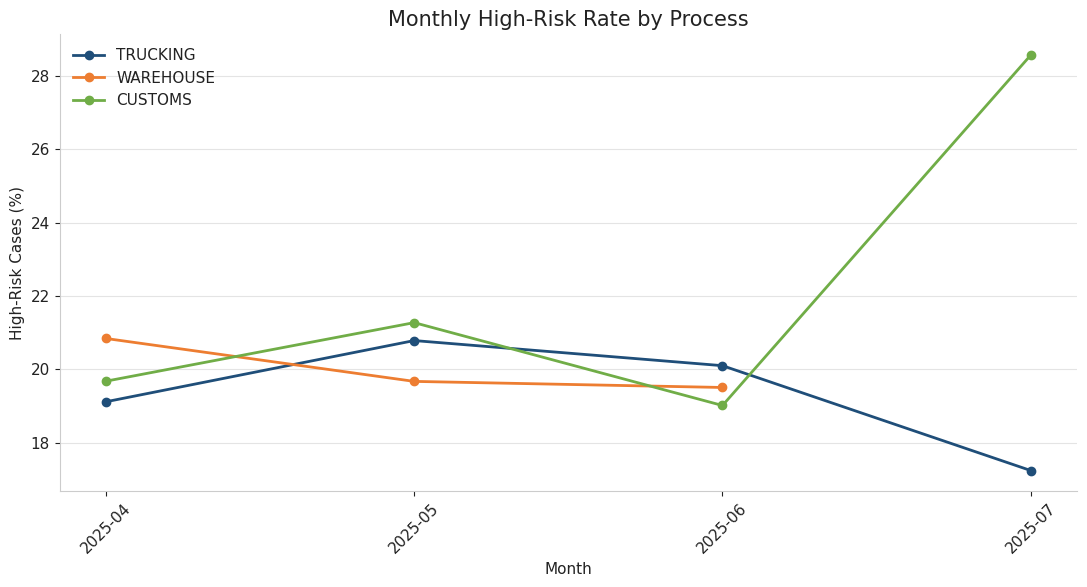

Saved: D:\logistics_AI\reports\cross_process\cross_process_monthly_high_risk_rate.png


In [64]:
# CELL 13

fig, ax = plt.subplots(figsize=(11, 6))

for process_key in PROCESS_KEYS:
    part = monthly_plot_df[monthly_plot_df["process_key"] == process_key].copy()
    if part.empty:
        continue

    ax.plot(
        part["month"],
        part["high_risk_rate"],
        marker="o",
        linewidth=2,
        label=process_key.upper(),
        color=PROCESS_COLOR_MAP.get(process_key, SECONDARY),
    )

ax.set_title("Monthly High-Risk Rate by Process")
ax.set_xlabel("Month")
ax.set_ylabel("High-Risk Cases (%)")
style_axes(ax, grid_axis="y")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

monthly_highrisk_path = SHARED_REPORT_DIR / "cross_process_monthly_high_risk_rate.png"
save_and_show(fig, monthly_highrisk_path)

In [65]:
# CELL 14

drift_view_df = drift_summary_all_df[
    [
        "process_key",
        "avg_risk_delta",
        "p95_risk_delta",
        "high_risk_rate_delta",
        "critical_rate_delta",
    ]
].copy()

for col in ["avg_risk_delta", "p95_risk_delta", "high_risk_rate_delta", "critical_rate_delta"]:
    drift_view_df[col] = pd.to_numeric(drift_view_df[col], errors="coerce")

display(drift_view_df)

,process_key,avg_risk_delta,p95_risk_delta,high_risk_rate_delta,critical_rate_delta
0,trucking,0.571821,0.666667,-0.625163,0.688379
1,warehouse,0.000000,0.000000,0.000000,0.000000
2,customs,-1.314314,-0.550000,2.964434,-1.374229


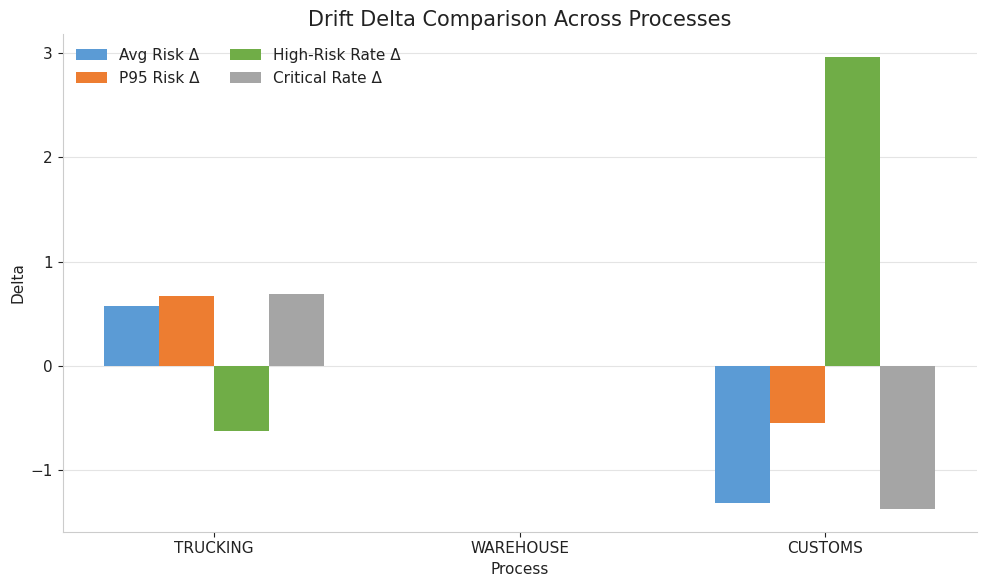

Saved: D:\logistics_AI\reports\cross_process\cross_process_drift_deltas.png


In [66]:
# CELL 15

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(drift_view_df))
width = 0.18

ax.bar(x - 1.5 * width, drift_view_df["avg_risk_delta"], width, label="Avg Risk Δ", color="#5b9bd5")
ax.bar(x - 0.5 * width, drift_view_df["p95_risk_delta"], width, label="P95 Risk Δ", color="#ed7d31")
ax.bar(x + 0.5 * width, drift_view_df["high_risk_rate_delta"], width, label="High-Risk Rate Δ", color="#70ad47")
ax.bar(x + 1.5 * width, drift_view_df["critical_rate_delta"], width, label="Critical Rate Δ", color="#a5a5a5")

ax.set_title("Drift Delta Comparison Across Processes")
ax.set_xlabel("Process")
ax.set_ylabel("Delta")
ax.set_xticks(x)
ax.set_xticklabels(drift_view_df["process_key"].str.upper())
style_axes(ax, grid_axis="y")
ax.legend(frameon=False, ncol=2)

drift_compare_path = SHARED_REPORT_DIR / "cross_process_drift_deltas.png"
save_and_show(fig, drift_compare_path)

In [67]:
# CELL 16

headline_df = portfolio_df.merge(
    drift_view_df,
    on="process_key",
    how="left",
)

headline_df = headline_df.sort_values(
    ["high_risk_rate_80plus", "p95_risk"],
    ascending=False,
)

display(headline_df)

,process_key,cases_analyzed,avg_risk,p95_risk,high_risk_rate_80plus,critical_rate,avg_risk_delta,p95_risk_delta,high_risk_rate_delta,critical_rate_delta
2,customs,4286,49.500700,94.75,0.200187,10.989267,-1.314314,-0.550000,2.964434,-1.374229
0,trucking,12000,49.500083,94.05,0.200000,23.608333,0.571821,0.666667,-0.625163,0.688379
1,warehouse,12000,49.500083,94.05,0.200000,18.991667,0.000000,0.000000,0.000000,0.000000


In [68]:
# CELL 17

summary_export_path = SHARED_REPORT_DIR / "cross_process_portfolio_summary.csv"
portfolio_df.to_csv(summary_export_path, index=False)

monitor_export_path = SHARED_REPORT_DIR / "cross_process_monthly_monitoring.csv"
monthly_plot_df.to_csv(monitor_export_path, index=False)

drift_export_path = SHARED_REPORT_DIR / "cross_process_drift_summary.csv"
drift_view_df.to_csv(drift_export_path, index=False)

headline_export_path = SHARED_REPORT_DIR / "cross_process_headline_table.csv"
headline_df.to_csv(headline_export_path, index=False)

generated_files = [
    SHARED_REPORT_DIR / "cross_process_risk_portfolio.png",
    SHARED_REPORT_DIR / "cross_process_high_risk_share.png",
    SHARED_REPORT_DIR / "cross_process_critical_share.png",
    SHARED_REPORT_DIR / "cross_process_monthly_avg_risk.png",
    SHARED_REPORT_DIR / "cross_process_monthly_high_risk_rate.png",
    SHARED_REPORT_DIR / "cross_process_drift_deltas.png",
    summary_export_path,
    monitor_export_path,
    drift_export_path,
    headline_export_path,
]

for f in generated_files:
    print(f.exists(), "-", f)

True - D:\logistics_AI\reports\cross_process\cross_process_risk_portfolio.png
True - D:\logistics_AI\reports\cross_process\cross_process_high_risk_share.png
True - D:\logistics_AI\reports\cross_process\cross_process_critical_share.png
True - D:\logistics_AI\reports\cross_process\cross_process_monthly_avg_risk.png
True - D:\logistics_AI\reports\cross_process\cross_process_monthly_high_risk_rate.png
True - D:\logistics_AI\reports\cross_process\cross_process_drift_deltas.png
True - D:\logistics_AI\reports\cross_process\cross_process_portfolio_summary.csv
True - D:\logistics_AI\reports\cross_process\cross_process_monthly_monitoring.csv
True - D:\logistics_AI\reports\cross_process\cross_process_drift_summary.csv
True - D:\logistics_AI\reports\cross_process\cross_process_headline_table.csv
